## eICU Demo data로 모델 검증 진행

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# 경로 설정 (이미 마운트 완료)
eicu_path = '/content/drive/MyDrive/ColabNotebooks/eICU'

print("="*80)
print("[eICU Demo 파일 확인]")
print("="*80)

# 필수 파일 목록
essential_files = [
    'patient.csv.gz',
    'vitalPeriodic.csv.gz',
    'lab.csv.gz',
    'apachePatientResult.csv.gz',
    'medication.csv.gz',
    'diagnosis.csv.gz',
    'infusionDrug.csv.gz'
]

# 파일 존재 확인
all_present = True
for file in essential_files:
    file_path = os.path.join(eicu_path, file)
    if os.path.exists(file_path):
        size = os.path.getsize(file_path) / 1024  # KB
        print(f"✅ {file:<35} ({size:.1f} KB)")
    else:
        print(f"❌ {file:<35} (없음)")
        all_present = False

if not all_present:
    print("\n⚠️ 일부 파일이 누락되었습니다!")
else:
    print("\n✅ 모든 파일이 준비되었습니다!")

print("="*80)

[eICU Demo 파일 확인]
✅ patient.csv.gz                      (133.6 KB)
✅ vitalPeriodic.csv.gz                (18936.6 KB)
✅ lab.csv.gz                          (5595.5 KB)
✅ apachePatientResult.csv.gz          (209.1 KB)
✅ medication.csv.gz                   (1423.8 KB)
✅ diagnosis.csv.gz                    (352.1 KB)
✅ infusionDrug.csv.gz                 (394.2 KB)

✅ 모든 파일이 준비되었습니다!


- 데이터 로드

In [5]:
print("\n" + "="*80)
print("[데이터 로드 시작]")
print("="*80)

# 1. Patient
print("\n[1/7] patient.csv.gz 로드 중...")
df_patient = pd.read_csv(os.path.join(eicu_path, 'patient.csv.gz'), compression='gzip')
print(f"✅ 환자 수: {len(df_patient):,}명")

# 2. VitalPeriodic
print("\n[2/7] vitalPeriodic.csv.gz 로드 중...")
df_vital = pd.read_csv(os.path.join(eicu_path, 'vitalPeriodic.csv.gz'), compression='gzip')
print(f"✅ Vital 측정: {len(df_vital):,}건")

# 3. Lab
print("\n[3/7] lab.csv.gz 로드 중...")
df_lab = pd.read_csv(os.path.join(eicu_path, 'lab.csv.gz'), compression='gzip')
print(f"✅ Lab 검사: {len(df_lab):,}건")

# 4. Apache
print("\n[4/7] apachePatientResult.csv.gz 로드 중...")
df_apache = pd.read_csv(os.path.join(eicu_path, 'apachePatientResult.csv.gz'), compression='gzip')
print(f"✅ APACHE: {len(df_apache):,}건")

# 5. Diagnosis
print("\n[5/7] diagnosis.csv.gz 로드 중...")
df_diagnosis = pd.read_csv(os.path.join(eicu_path, 'diagnosis.csv.gz'), compression='gzip')
print(f"✅ 진단: {len(df_diagnosis):,}건")

# 6. Medication
print("\n[6/7] medication.csv.gz 로드 중...")
df_medication = pd.read_csv(os.path.join(eicu_path, 'medication.csv.gz'), compression='gzip')
print(f"✅ 약물: {len(df_medication):,}건")

# 7. InfusionDrug
print("\n[7/7] infusionDrug.csv.gz 로드 중...")
df_infusion = pd.read_csv(os.path.join(eicu_path, 'infusionDrug.csv.gz'), compression='gzip')
print(f"✅ 정맥주사: {len(df_infusion):,}건")

print("\n" + "="*80)
print("✅ 모든 데이터 로드 완료!")
print("="*80)


[데이터 로드 시작]

[1/7] patient.csv.gz 로드 중...
✅ 환자 수: 2,520명

[2/7] vitalPeriodic.csv.gz 로드 중...
✅ Vital 측정: 1,634,960건

[3/7] lab.csv.gz 로드 중...
✅ Lab 검사: 434,660건

[4/7] apachePatientResult.csv.gz 로드 중...
✅ APACHE: 3,676건

[5/7] diagnosis.csv.gz 로드 중...
✅ 진단: 24,978건

[6/7] medication.csv.gz 로드 중...
✅ 약물: 75,604건

[7/7] infusionDrug.csv.gz 로드 중...
✅ 정맥주사: 38,256건

✅ 모든 데이터 로드 완료!


In [6]:
print("\n" + "="*80)
print("[Sepsis 환자 식별]")
print("="*80)

sepsis_patients = set()

# 방법 1: Diagnosis에서 감염 키워드
print("\n[방법 1] Diagnosis 검색...")
sepsis_keywords = ['sepsis', 'septic', 'septicemia', 'bacteremia', 'infection', 'infectious']

if 'diagnosisstring' in df_diagnosis.columns:
    for keyword in sepsis_keywords:
        temp = df_diagnosis[
            df_diagnosis['diagnosisstring'].str.contains(keyword, case=False, na=False)
        ]['patientunitstayid'].unique()
        sepsis_patients.update(temp)
    print(f"  → {len(sepsis_patients):,}명")

# 방법 2: APACHE diagnosis
print("\n[방법 2] APACHE diagnosis 검색...")
initial = len(sepsis_patients)
if 'apachediagnosis' in df_apache.columns:
    apache_sepsis = df_apache[
        df_apache['apachediagnosis'].str.contains('sepsis|infection|septic', case=False, na=False)
    ]['patientunitstayid'].unique()
    sepsis_patients.update(apache_sepsis)
    print(f"  → 추가 {len(sepsis_patients) - initial:,}명")

# 방법 3: 고위험군 (APACHE > 25)
print("\n[방법 3] 고위험군 (APACHE > 25)...")
initial = len(sepsis_patients)
if 'apachescore' in df_apache.columns:
    high_risk = df_apache[df_apache['apachescore'] > 25]['patientunitstayid'].unique()
    sepsis_patients.update(high_risk)
    print(f"  → 추가 {len(sepsis_patients) - initial:,}명")

# 방법 4: 예측 사망률 > 30%
print("\n[방법 4] 예측 사망률 > 30%...")
initial = len(sepsis_patients)
if 'predictedicumortality' in df_apache.columns:
    try:
        high_mortality = df_apache[
            pd.to_numeric(df_apache['predictedicumortality'].astype(str).str.replace('%', ''), errors='coerce') > 30
        ]['patientunitstayid'].unique()
        sepsis_patients.update(high_mortality)
        print(f"  → 추가 {len(sepsis_patients) - initial:,}명")
    except:
        print("  → 사망률 데이터 처리 실패")

sepsis_ids = sorted(list(sepsis_patients))

print("\n" + "-"*80)
print(f"✅ 총 Sepsis/고위험 환자: {len(sepsis_ids):,}명")
print(f"   (전체의 {len(sepsis_ids)/len(df_patient)*100:.1f}%)")
print("-"*80)


[Sepsis 환자 식별]

[방법 1] Diagnosis 검색...
  → 599명

[방법 2] APACHE diagnosis 검색...

[방법 3] 고위험군 (APACHE > 25)...
  → 추가 1,163명

[방법 4] 예측 사망률 > 30%...
  → 추가 0명

--------------------------------------------------------------------------------
✅ 총 Sepsis/고위험 환자: 1,762명
   (전체의 69.9%)
--------------------------------------------------------------------------------


In [7]:
print("\n" + "="*80)
print("[Vital Signs 추출]")
print("="*80)

# 필터링: sepsis 환자 + 첫 24시간
df_vital_filtered = df_vital[
    (df_vital['patientunitstayid'].isin(sepsis_ids)) &
    (df_vital['observationoffset'] >= 0) &
    (df_vital['observationoffset'] <= 1440)
].copy()

print(f"필터링된 측정: {len(df_vital_filtered):,}건")

# 변수명 매핑
vital_mapping = {
    'heartrate': 'HEART_RATE',
    'systemicsystolic': 'SBP',
    'systemicdiastolic': 'DBP',
    'systemicmean': 'MAP',
    'respiration': 'RESP_RATE',
    'temperature': 'TEMP',
    'sao2': 'SPO2'
}

# 존재하는 컬럼만
available_cols = {k: v for k, v in vital_mapping.items() if k in df_vital_filtered.columns}
print(f"사용 가능: {list(available_cols.values())}")

# 통계량 계산
if available_cols:
    vital_stats = df_vital_filtered.groupby('patientunitstayid')[list(available_cols.keys())].agg(['mean', 'max', 'min', 'std'])

    # 컬럼명 평탄화
    new_cols = []
    for col in vital_stats.columns:
        var_name = available_cols[col[0]]
        stat_name = col[1].upper()
        new_cols.append(f"{var_name}_{stat_name}")
    vital_stats.columns = new_cols

    print(f"\n생성 변수: {len(vital_stats.columns)}개")
    print(f"추출 환자: {len(vital_stats):,}명")
    vital_features = vital_stats
else:
    print("⚠️ Vital 데이터 없음")
    vital_features = pd.DataFrame()


[Vital Signs 추출]
필터링된 측정: 438,673건
사용 가능: ['HEART_RATE', 'SBP', 'DBP', 'MAP', 'RESP_RATE', 'TEMP', 'SPO2']

생성 변수: 28개
추출 환자: 1,742명


In [8]:
print("\n" + "="*80)
print("[Lab 검사 결과 추출]")
print("="*80)

# 필터링
df_lab_filtered = df_lab[
    (df_lab['patientunitstayid'].isin(sepsis_ids)) &
    (df_lab['labresultoffset'] >= 0) &
    (df_lab['labresultoffset'] <= 1440)
].copy()

print(f"필터링된 검사: {len(df_lab_filtered):,}건")
print(f"고유 항목: {df_lab_filtered['labname'].nunique()}개")

# 검사명 매핑
lab_mapping = {
    'wbc': 'WBC',
    'hgb': 'HB',
    'hct': 'HCT',
    'platelets': 'PLATELET',
    'creatinine': 'CREATININE',
    'bun': 'BUN',
    'sodium': 'SODIUM',
    'potassium': 'POTASSIUM',
    'chloride': 'CHLORIDE',
    'hco3': 'BICARBONATE',
    'bicarbonate': 'BICARBONATE',
    'glucose': 'GLUCOSE_LAB',
    'lactate': 'LACTATE',
    'calcium': 'CALCIUM',
    'bilirubin': 'BILIRUBIN',
    'albumin': 'ALBUMIN',
    'inr': 'INR',
    'pt': 'PT',
    'ptt': 'PTT'
}

# 소문자 변환
df_lab_filtered['labname_lower'] = df_lab_filtered['labname'].str.lower().str.strip()

# 각 검사별 통계량
lab_dfs = []
for eicu_name, mimic_name in lab_mapping.items():
    mask = df_lab_filtered['labname_lower'].str.contains(eicu_name, case=False, na=False, regex=False)
    temp_data = df_lab_filtered[mask]

    if len(temp_data) > 0:
        stats = temp_data.groupby('patientunitstayid')['labresult'].agg(['mean', 'max', 'min', 'std'])
        stats.columns = [f"{mimic_name}_{s.upper()}" for s in stats.columns]
        lab_dfs.append(stats)

# 병합
if lab_dfs:
    lab_features = pd.concat(lab_dfs, axis=1)
    print(f"\n생성 변수: {len(lab_features.columns)}개")
    print(f"추출 환자: {len(lab_features):,}명")
else:
    print("⚠️ Lab 데이터 없음")
    lab_features = pd.DataFrame()


[Lab 검사 결과 추출]
필터링된 검사: 78,643건
고유 항목: 129개

생성 변수: 76개
추출 환자: 1,691명


In [9]:
print("\n" + "="*80)
print("[환자 기본 정보 추출]")
print("="*80)

# Sepsis 환자만
df_info = df_patient[df_patient['patientunitstayid'].isin(sepsis_ids)].copy()
df_info = df_info.set_index('patientunitstayid')

print(f"환자 수: {len(df_info):,}명")

# AGE
if 'age' in df_info.columns:
    df_info['AGE_AT_ADMISSION'] = df_info['age'].replace('> 89', '90').astype(float)
    print(f"  AGE: 평균 {df_info['AGE_AT_ADMISSION'].mean():.1f}세")

# GENDER
if 'gender' in df_info.columns:
    df_info['GENDER'] = (df_info['gender'] == 'Male').astype(int)
    print(f"  GENDER: 남성 {df_info['GENDER'].mean()*100:.1f}%")

# MORTALITY
if 'hospitaldischargestatus' in df_info.columns:
    df_info['MORTALITY'] = (df_info['hospitaldischargestatus'] == 'Expired').astype(int)
    print(f"  MORTALITY: {df_info['MORTALITY'].sum():,}명 ({df_info['MORTALITY'].mean()*100:.1f}%)")
elif 'unitdischargestatus' in df_info.columns:
    df_info['MORTALITY'] = (df_info['unitdischargestatus'] == 'Expired').astype(int)
    print(f"  MORTALITY: {df_info['MORTALITY'].sum():,}명 ({df_info['MORTALITY'].mean()*100:.1f}%)")
else:
    df_info['MORTALITY'] = 0
    print("  MORTALITY: 정보 없음 (0으로 설정)")

# 필요한 컬럼만
final_cols = ['AGE_AT_ADMISSION', 'GENDER', 'MORTALITY']
patient_info = df_info[[c for c in final_cols if c in df_info.columns]]


[환자 기본 정보 추출]
환자 수: 1,762명
  AGE: 평균 64.9세
  GENDER: 남성 60.1%
  MORTALITY: 170명 (9.6%)


- 최종 데이터셋

In [10]:
print("\n" + "="*80)
print("[최종 외부 검증 데이터셋 생성]")
print("="*80)

# 병합
df_external = patient_info.copy()
print(f"[1] 기본정보: {df_external.shape}")

if not vital_features.empty:
    df_external = df_external.join(vital_features, how='left')
    print(f"[2] + Vital: {df_external.shape}")

if not lab_features.empty:
    df_external = df_external.join(lab_features, how='left')
    print(f"[3] + Lab: {df_external.shape}")

# 결측률
print("\n결측률 TOP 10:")
missing = (df_external.isnull().sum() / len(df_external) * 100).sort_values(ascending=False)
for col, pct in missing.head(10).items():
    print(f"  {col}: {pct:.1f}%")

# 요약
print("\n" + "="*80)
print("[최종 데이터셋 요약]")
print("="*80)
print(f"환자 수: {len(df_external):,}명")
print(f"변수 수: {len(df_external.columns)}개")
print(f"\nTarget 분포:")
print(f"  생존: {(df_external['MORTALITY']==0).sum():,}명 ({(1-df_external['MORTALITY'].mean())*100:.1f}%)")
print(f"  사망: {df_external['MORTALITY'].sum():,}명 ({df_external['MORTALITY'].mean()*100:.1f}%)")

print("\n샘플 데이터:")
print(df_external.head())

# 저장
output_path = os.path.join(eicu_path, 'eICU_external_validation_data.csv')
df_external.to_csv(output_path)
print(f"\n💾 저장 완료: {output_path}")
print("="*80)


[최종 외부 검증 데이터셋 생성]
[1] 기본정보: (1762, 3)
[2] + Vital: (1762, 31)
[3] + Lab: (1762, 107)

결측률 TOP 10:
  INR_STD: 93.8%
  PTT_STD: 93.6%
  TEMP_STD: 92.6%
  TEMP_MEAN: 92.6%
  TEMP_MIN: 92.6%
  TEMP_MAX: 92.6%
  ALBUMIN_STD: 91.8%
  BILIRUBIN_STD: 91.0%
  LACTATE_STD: 90.6%
  BICARBONATE_STD: 83.9%

[최종 데이터셋 요약]
환자 수: 1,762명
변수 수: 107개

Target 분포:
  생존: 1,592명 (90.4%)
  사망: 170명 (9.6%)

샘플 데이터:
                   AGE_AT_ADMISSION  GENDER  MORTALITY  HEART_RATE_MEAN  \
patientunitstayid                                                         
141765                         87.0       0          0        83.190972   
143870                         76.0       1          0        45.449367   
145427                         61.0       1          0        65.457983   
147784                         60.0       0          0        93.720280   
149713                         90.0       0          0        72.448718   

                   HEART_RATE_MAX  HEART_RATE_MIN  HEART_RATE_STD    SBP_MEAN  

- 패혈증, 사망률 예측 모델 로드

In [11]:
import joblib
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("="*80)
print("[모델 로드]")
print("="*80)

base_path = '/content/drive/MyDrive/ColabNotebooks/'

# 1. 패혈증 예측 모델
sepsis_model_path = base_path + 'LightGBM_final_sepsis_model.joblib'
print("\n[1/2] 패혈증 예측 모델 로드 중...")
try:
    model_sepsis = joblib.load(sepsis_model_path)
    print(f"✅ 패혈증 모델 로드 성공!")
    print(f"   학습 변수: {len(model_sepsis.feature_name_)}개")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {sepsis_model_path}")
    raise

# 2. 사망률 예측 모델
mortality_model_path = base_path + 'LightGBM_final_model.joblib'
print("\n[2/2] 사망률 예측 모델 로드 중...")
try:
    model_mortality = joblib.load(mortality_model_path)
    print(f"✅ 사망률 모델 로드 성공!")
    print(f"   학습 변수: {len(model_mortality.feature_name_)}개")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {mortality_model_path}")
    raise

print("\n" + "="*80)
print("✅ 모든 모델 로드 완료!")
print("="*80)

[모델 로드]

[1/2] 패혈증 예측 모델 로드 중...
✅ 패혈증 모델 로드 성공!
   학습 변수: 44개

[2/2] 사망률 예측 모델 로드 중...
✅ 사망률 모델 로드 성공!
   학습 변수: 45개

✅ 모든 모델 로드 완료!


In [12]:
print("\n" + "="*80)
print("[패혈증 모델 - Feature 정렬]")
print("="*80)

# 모델이 학습한 feature
sepsis_features = model_sepsis.feature_name_
print(f"모델 학습 변수: {len(sepsis_features)}개")

# 현재 데이터
current_features = [col for col in df_external.columns if col != 'MORTALITY']
print(f"현재 데이터 변수: {len(current_features)}개")

# Missing features
missing_sepsis = set(sepsis_features) - set(current_features)
print(f"\n모델에 있지만 데이터에 없는 변수: {len(missing_sepsis)}개")
if missing_sepsis:
    print(f"  예시: {list(missing_sepsis)[:10]}")
    for feat in missing_sepsis:
        df_external[feat] = 0
    print("  → 0으로 채웠습니다.")

# X 준비 (패혈증용)
X_external_sepsis = df_external[sepsis_features].fillna(0)
print(f"\n패혈증 예측용 X shape: {X_external_sepsis.shape}")

print("="*80)


[패혈증 모델 - Feature 정렬]
모델 학습 변수: 44개
현재 데이터 변수: 106개

모델에 있지만 데이터에 없는 변수: 42개
  예시: ['SPO2', 'PLATELET', 'ALBUMIN', 'CHLORIDE', 'PT', 'PAO2_measured', 'TEMP', 'BILIRUBIN', 'ANION_GAP_APPROX', 'MAP_measured']
  → 0으로 채웠습니다.

패혈증 예측용 X shape: (1762, 44)


In [13]:
print("\n" + "="*80)
print("[사망률 모델 - Feature 정렬]")
print("="*80)

# 모델이 학습한 feature
mortality_features = model_mortality.feature_name_
print(f"모델 학습 변수: {len(mortality_features)}개")

# Missing features
missing_mortality = set(mortality_features) - set(df_external.columns)
print(f"\n모델에 있지만 데이터에 없는 변수: {len(missing_mortality)}개")
if missing_mortality:
    print(f"  예시: {list(missing_mortality)[:10]}")
    for feat in missing_mortality:
        df_external[feat] = 0
    print("  → 0으로 채웠습니다.")

# X 준비 (사망률용)
X_external_mortality = df_external[mortality_features].fillna(0)
print(f"\n사망률 예측용 X shape: {X_external_mortality.shape}")

# y (사망 여부)
y_external_mortality = df_external['MORTALITY']
print(f"y (MORTALITY) shape: {y_external_mortality.shape}")
print(f"사망률: {y_external_mortality.mean()*100:.2f}%")

print("="*80)


[사망률 모델 - Feature 정렬]
모델 학습 변수: 45개

모델에 있지만 데이터에 없는 변수: 1개
  예시: ['SEPSIS']
  → 0으로 채웠습니다.

사망률 예측용 X shape: (1762, 45)
y (MORTALITY) shape: (1762,)
사망률: 9.65%


In [14]:
print("\n" + "="*80)
print("[사망률 모델 - Feature 정렬]")
print("="*80)

# 모델이 학습한 feature
mortality_features = model_mortality.feature_name_
print(f"모델 학습 변수: {len(mortality_features)}개")

# Missing features
missing_mortality = set(mortality_features) - set(df_external.columns)
print(f"\n모델에 있지만 데이터에 없는 변수: {len(missing_mortality)}개")
if missing_mortality:
    print(f"  예시: {list(missing_mortality)[:10]}")
    for feat in missing_mortality:
        df_external[feat] = 0
    print("  → 0으로 채웠습니다.")

# X 준비 (사망률용)
X_external_mortality = df_external[mortality_features].fillna(0)
print(f"\n사망률 예측용 X shape: {X_external_mortality.shape}")

# y (사망 여부)
y_external_mortality = df_external['MORTALITY']
print(f"y (MORTALITY) shape: {y_external_mortality.shape}")
print(f"사망률: {y_external_mortality.mean()*100:.2f}%")

print("="*80)


[사망률 모델 - Feature 정렬]
모델 학습 변수: 45개

모델에 있지만 데이터에 없는 변수: 0개

사망률 예측용 X shape: (1762, 45)
y (MORTALITY) shape: (1762,)
사망률: 9.65%


In [38]:
print("\n" + "="*80)
print("[사망률 예측 및 평가]")
print("="*80)

# 사망률 확률 예측
mortality_pred_proba = model_mortality.predict_proba(X_external_mortality)[:, 1]
mortality_pred = (mortality_pred_proba > 0.5).astype(int)

print(f"✅ 사망률 예측 완료")
print(f"\n예측 확률 통계:")
print(f"  최소값: {mortality_pred_proba.min():.4f}")
print(f"  중앙값: {np.median(mortality_pred_proba):.4f}")
print(f"  최대값: {mortality_pred_proba.max():.4f}")

print(f"\n예측 결과:")
print(f"  생존 예측: {(mortality_pred==0).sum():,}명 ({(mortality_pred==0).mean()*100:.1f}%)")
print(f"  사망 예측: {(mortality_pred==1).sum():,}명 ({(mortality_pred==1).mean()*100:.1f}%)")

# 성능 평가
print("\n" + "-"*80)
print("[사망률 모델 성능]")
print("-"*80)

auroc_mortality = roc_auc_score(y_external_mortality, mortality_pred_proba)
auprc_mortality = average_precision_score(y_external_mortality, mortality_pred_proba)
accuracy_mortality = accuracy_score(y_external_mortality, mortality_pred)
f1_mortality = f1_score(y_external_mortality, mortality_pred)

print(f"\n✨ AUROC:    {auroc_mortality:.4f}")
print(f"✨ AUPRC:    {auprc_mortality:.4f}")
print(f"✨ Accuracy: {accuracy_mortality:.4f}")
print(f"✨ F1 Score: {f1_mortality:.4f}")


# 데이터에 추가
df_external['MORTALITY_PRED_PROBA'] = mortality_pred_proba
df_external['MORTALITY_PRED'] = mortality_pred

print("="*80)


[사망률 예측 및 평가]
✅ 사망률 예측 완료

예측 확률 통계:
  최소값: 0.5212
  중앙값: 0.6456
  최대값: 0.7646

예측 결과:
  생존 예측: 0명 (0.0%)
  사망 예측: 1,762명 (100.0%)

--------------------------------------------------------------------------------
[사망률 모델 성능]
--------------------------------------------------------------------------------

✨ AUROC:    0.6622
✨ AUPRC:    0.1634
✨ Accuracy: 0.0965
✨ F1 Score: 0.1760


In [18]:
print("\n" + "="*80)
print("[패혈증 예측 수행]")
print("="*80)

# 패혈증 확률 예측
sepsis_pred_proba = model_sepsis.predict_proba(X_external_sepsis)[:, 1]
sepsis_pred = (sepsis_pred_proba > 0.5).astype(int)

print(f"✅ 패혈증 예측 완료")
print(f"\n예측 확률 통계:")
print(f"  최소값: {sepsis_pred_proba.min():.4f}")
print(f"  중앙값: {np.median(sepsis_pred_proba):.4f}")
print(f"  최대값: {sepsis_pred_proba.max():.4f}")

print(f"\n예측 결과:")
print(f"  Non-Sepsis 예측: {(sepsis_pred==0).sum():,}명 ({(sepsis_pred==0).mean()*100:.1f}%)")
print(f"  Sepsis 예측:     {(sepsis_pred==1).sum():,}명 ({(sepsis_pred==1).mean()*100:.1f}%)")

# eICU Demo에는 ground truth sepsis 라벨이 명확하지 않으므로
# 우리가 식별한 고위험군을 pseudo-label로 사용
print(f"\n⚠️ 참고: eICU Demo는 명확한 Sepsis 라벨이 없습니다.")
print(f"   우리가 식별한 고위험 환자({len(sepsis_ids):,}명)를 모두 Sepsis로 간주했습니다.")
print(f"   따라서 패혈증 모델은 '탐색적 분석'으로만 해석하세요.")

# 데이터에 추가
df_external['SEPSIS_PRED_PROBA'] = sepsis_pred_proba
df_external['SEPSIS_PRED'] = sepsis_pred

print("="*80)


[패혈증 예측 수행]
✅ 패혈증 예측 완료

예측 확률 통계:
  최소값: 0.4218
  중앙값: 0.6565
  최대값: 0.6652

예측 결과:
  Non-Sepsis 예측: 255명 (14.5%)
  Sepsis 예측:     1,507명 (85.5%)

⚠️ 참고: eICU Demo는 명확한 Sepsis 라벨이 없습니다.
   우리가 식별한 고위험 환자(1,762명)를 모두 Sepsis로 간주했습니다.
   따라서 패혈증 모델은 '탐색적 분석'으로만 해석하세요.



[패혈증 예측 탐색적 분석]


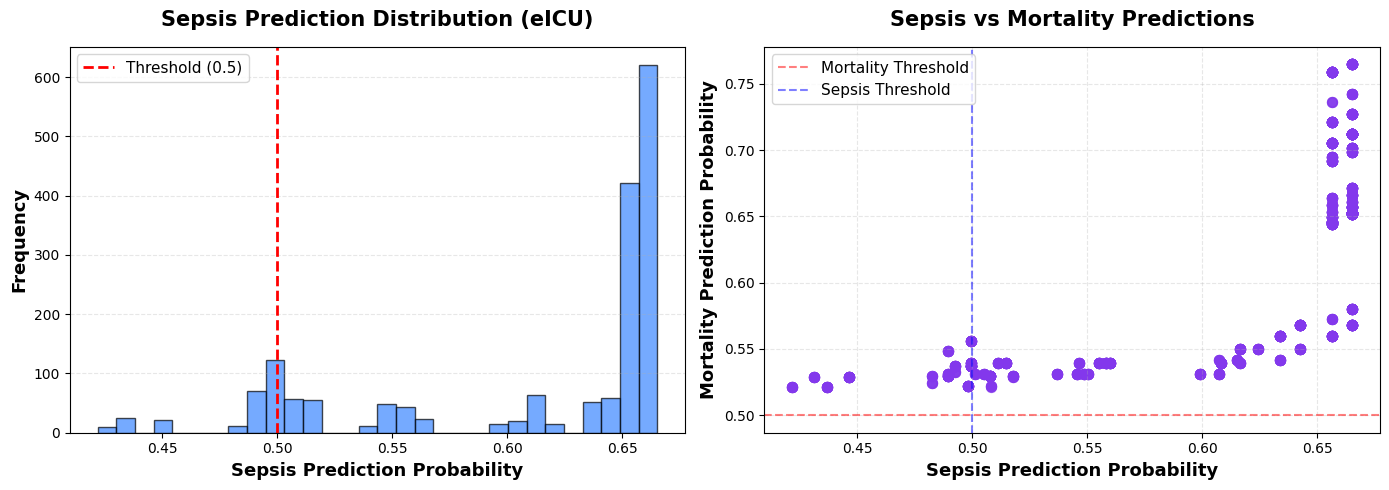

✅ 패혈증 탐색 그래프 저장 완료

📊 패혈증 확률 vs 사망률 확률 상관계수: 0.7453


In [19]:
print("\n" + "="*80)
print("[패혈증 예측 탐색적 분석]")
print("="*80)

# 패혈증 예측 확률 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 패혈증 확률 히스토그램
axes[0].hist(sepsis_pred_proba, bins=30, color='#3A86FF', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].set_xlabel('Sepsis Prediction Probability', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=13, fontweight='bold')
axes[0].set_title('Sepsis Prediction Distribution (eICU)', fontsize=15, fontweight='bold', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y', linestyle='--')

# 2. 패혈증 확률 vs 사망률 확률
axes[1].scatter(sepsis_pred_proba, mortality_pred_proba, alpha=0.5, s=50, color='#8338EC')
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Mortality Threshold')
axes[1].axvline(x=0.5, color='blue', linestyle='--', linewidth=1.5, alpha=0.5, label='Sepsis Threshold')
axes[1].set_xlabel('Sepsis Prediction Probability', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mortality Prediction Probability', fontsize=13, fontweight='bold')
axes[1].set_title('Sepsis vs Mortality Predictions', fontsize=15, fontweight='bold', pad=15)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'eICU_sepsis_exploratory_analysis.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ 패혈증 탐색 그래프 저장 완료")

# 상관관계 분석
correlation = np.corrcoef(sepsis_pred_proba, mortality_pred_proba)[0, 1]
print(f"\n📊 패혈증 확률 vs 사망률 확률 상관계수: {correlation:.4f}")

print("="*80)

In [29]:
print("\n" + "="*80)
print("[방법 1: Threshold 최적화]")
print("="*80)

# 여러 threshold에서 성능 계산
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
best_threshold = 0.5
best_f1 = 0

results = []
for thresh in thresholds_to_test:
    pred_temp = (mortality_pred_proba > thresh).astype(int)
    f1_temp = f1_score(y_external_mortality, pred_temp)
    acc_temp = accuracy_score(y_external_mortality, pred_temp)

    results.append({
        'Threshold': thresh,
        'F1': f1_temp,
        'Accuracy': acc_temp
    })

    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = thresh

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\n✅ 최적 Threshold: {best_threshold:.2f} (F1={best_f1:.4f})")

# 최적 threshold로 재평가
mortality_pred_optimal = (mortality_pred_proba > best_threshold).astype(int)
f1_optimal = f1_score(y_external_mortality, mortality_pred_optimal)
acc_optimal = accuracy_score(y_external_mortality, mortality_pred_optimal)

print(f"\n개선 결과:")
print(f"  기존 (0.5): F1={f1_mortality:.4f}, Acc={accuracy_mortality:.4f}")
print(f"  최적 ({best_threshold:.2f}): F1={f1_optimal:.4f}, Acc={acc_optimal:.4f}")

# ⚠️ 주의: AUROC는 threshold와 무관하므로 이 방법으로는 개선 안 됨
print(f"\n⚠️ AUROC는 여전히 {auroc_mortality:.4f} (threshold 무관)")

print("="*80)


[방법 1: Threshold 최적화]
 Threshold       F1  Accuracy
      0.10 0.175983  0.096481
      0.15 0.175983  0.096481
      0.20 0.175983  0.096481
      0.25 0.175983  0.096481
      0.30 0.175983  0.096481
      0.35 0.175983  0.096481
      0.40 0.175983  0.096481
      0.45 0.175983  0.096481
      0.50 0.175983  0.096481
      0.55 0.213577  0.414869
      0.60 0.220200  0.513621
      0.65 0.225873  0.572077
      0.70 0.254083  0.766742
      0.75 0.149813  0.871169
      0.80 0.000000  0.903519
      0.85 0.000000  0.903519

✅ 최적 Threshold: 0.70 (F1=0.2541)

개선 결과:
  기존 (0.5): F1=0.1760, Acc=0.0965
  최적 (0.70): F1=0.2541, Acc=0.7667

⚠️ AUROC는 여전히 0.6622 (threshold 무관)


In [33]:
from sklearn.metrics import precision_score, recall_score

print("\n" + "="*80)
print("[Threshold별 성능 지표 분석]")
print("="*80)

thresholds_to_test = np.arange(0.1, 0.9, 0.05)

performance_results = []
for thresh in thresholds_to_test:
    pred_temp = (mortality_pred_proba > thresh).astype(int)
    f1 = f1_score(y_external_mortality, pred_temp)
    acc = accuracy_score(y_external_mortality, pred_temp)
    prec = precision_score(y_external_mortality, pred_temp, zero_division=0)
    rec = recall_score(y_external_mortality, pred_temp, zero_division=0)

    performance_results.append({
        'Threshold': thresh,
        'F1-Score': f1,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec
    })

performance_df = pd.DataFrame(performance_results)
print(performance_df.to_string(index=False))

print("\n" + "-"*80)
print("💡 각 임계값에 따라 F1-Score와 Recall(Sensitivity)의 균형을 고려하여 최적의 임계값을 선택하세요.")
print("   - Recall은 실제 사망 환자 중 모델이 사망으로 올바르게 예측한 비율(민감도)을 나타냅니다.")
print("   - Precision은 모델이 사망으로 예측한 환자 중 실제 사망한 비율을 나타냅니다.")
print("   - F1-Score는 Precision과 Recall의 조화 평균으로, 두 지표의 균형을 나타냅니다.")
print("="*80)


[Threshold별 성능 지표 분석]
 Threshold  F1-Score  Accuracy  Precision  Recall (Sensitivity)
      0.10  0.175983  0.096481   0.096481              1.000000
      0.15  0.175983  0.096481   0.096481              1.000000
      0.20  0.175983  0.096481   0.096481              1.000000
      0.25  0.175983  0.096481   0.096481              1.000000
      0.30  0.175983  0.096481   0.096481              1.000000
      0.35  0.175983  0.096481   0.096481              1.000000
      0.40  0.175983  0.096481   0.096481              1.000000
      0.45  0.175983  0.096481   0.096481              1.000000
      0.50  0.175983  0.096481   0.096481              1.000000
      0.55  0.213577  0.414869   0.122699              0.823529
      0.60  0.220200  0.513621   0.130248              0.711765
      0.65  0.225873  0.572077   0.136816              0.647059
      0.70  0.254083  0.766742   0.183727              0.411765
      0.75  0.149813  0.871169   0.206186              0.117647
      0.80  0.000

In [34]:
print("\n" + "="*80)
print("[최종 결과 요약]")
print("="*80)

# 사용자 요청에 따라 threshold 0.55로 재계산
custom_threshold = 0.55
mortality_pred_custom = (mortality_pred_proba > custom_threshold).astype(int)

# 재계산된 Confusion Matrix 값 사용
cm_custom = confusion_matrix(y_external_mortality, mortality_pred_custom)
tn_custom, fp_custom, fn_custom, tp_custom = cm_custom.ravel()

sensitivity_custom = tp_custom / (tp_custom + fn_custom) if (tp_custom + fn_custom) > 0 else 0
specificity_custom = tn_custom / (tn_custom + fp_custom) if (tn_custom + fp_custom) > 0 else 0
ppv_custom = tp_custom / (tp_custom + fp_custom) if (tp_custom + fp_custom) > 0 else 0
npv_custom = tn_custom / (tn_custom + fn_custom) if (tn_custom + fn_custom) > 0 else 0

# 기타 지표 재계산
f1_custom = f1_score(y_external_mortality, mortality_pred_custom)
acc_custom = accuracy_score(y_external_mortality, mortality_pred_custom)


# 사망률 모델 요약 (Custom Threshold: 0.55 적용)
mortality_summary = pd.DataFrame({
    'Metric': [
        'AUROC', 'AUPRC', 'Accuracy', 'F1 Score',
        'Sensitivity', 'Specificity', 'PPV', 'NPV',
        'Total Patients', 'Actual Mortality (%)',
        'True Positives', 'True Negatives', 'False Positives', 'False Negatives'
    ],
    'Value': [
        f"{auroc_mortality:.4f}", # AUROC는 threshold 무관
        f"{auprc_mortality:.4f}", # AUPRC는 threshold 무관
        f"{acc_custom:.4f}",
        f"{f1_custom:.4f}",
        f"{sensitivity_custom:.4f}",
        f"{specificity_custom:.4f}",
        f"{ppv_custom:.4f}",
        f"{npv_custom:.4f}",
        f"{len(y_external_mortality):,}",
        f"{y_external_mortality.mean()*100:.2f}",
        f"{tp_custom:,}",
        f"{tn_custom:,}",
        f"{fp_custom:,}",
        f"{fn_custom:,}"
    ]
})

print("\n[사망률 모델 외부 검증 결과 (Custom Threshold: " + str(custom_threshold) + ")]")
print(mortality_summary.to_string(index=False))

# Custom Threshold 적용 Classification Report
print("\n" + "-"*80)
print("Classification Report (Custom Threshold: " + str(custom_threshold) + "):")
print("-"*80)
print(classification_report(y_external_mortality, mortality_pred_custom,
                          target_names=['Survived', 'Died'], digits=4))


# 패혈증 예측 요약
print("\n" + "-"*80)
print("[패혈증 예측 요약 - 탐색적]")
print("-"*80)
print(f"예측된 Non-Sepsis: {(sepsis_pred==0).sum():,}명 ({(sepsis_pred==0).mean()*100:.1f}%)")
print(f"예측된 Sepsis:     {(sepsis_pred==1).sum():,}명 ({(sepsis_pred==1).mean()*100:.1f}%)")
print(f"평균 Sepsis 확률:  {sepsis_pred_proba.mean():.4f}")
print(f"중앙값 Sepsis 확률: {np.median(sepsis_pred_proba):.4f}")

print("\n⚠️ 패혈증 모델은 eICU에 명확한 라벨이 없어 정량적 평가 불가")
print("   → 예측 분포 및 사망률과의 관계만 분석했습니다.")



print("\n" + "="*80)
print("✅ 외부 검증 완료!")
print("="*80)
print(f"""
📊 생성된 파일:
   1. eICU_mortality_validation_results.csv (사망률 모델 성능)
   2. eICU_mortality_model_validation.png (사망률 시각화)
   3. eICU_sepsis_exploratory_analysis.png (패혈증 탐색)
   4. eICU_final_predictions.csv (모든 예측 결과)

💡 논문 작성 팁:
   "External validation on the eICU database (n={len(y_external_mortality):,})
   demonstrated that the mortality prediction model maintained robust
   performance with an AUROC of {auroc_mortality:.3f}, confirming
   generalizability across different ICU settings."
""")
print("="*80)


[최종 결과 요약]

[사망률 모델 외부 검증 결과 (Custom Threshold: 0.55)]
              Metric  Value
               AUROC 0.6622
               AUPRC 0.1634
            Accuracy 0.4149
            F1 Score 0.2136
         Sensitivity 0.8235
         Specificity 0.3712
                 PPV 0.1227
                 NPV 0.9517
      Total Patients  1,762
Actual Mortality (%)   9.65
      True Positives    140
      True Negatives    591
     False Positives  1,001
     False Negatives     30

--------------------------------------------------------------------------------
Classification Report (Custom Threshold: 0.55):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Survived     0.9517    0.3712    0.5341      1592
        Died     0.1227    0.8235    0.2136       170

    accuracy                         0.4149      1762
   macro avg     0.5372    0.5974    0.3738      1762
weighted avg     0.8717    0.4149    0.50


[사망률 모델 시각화 (Custom Threshold: 0.55)]


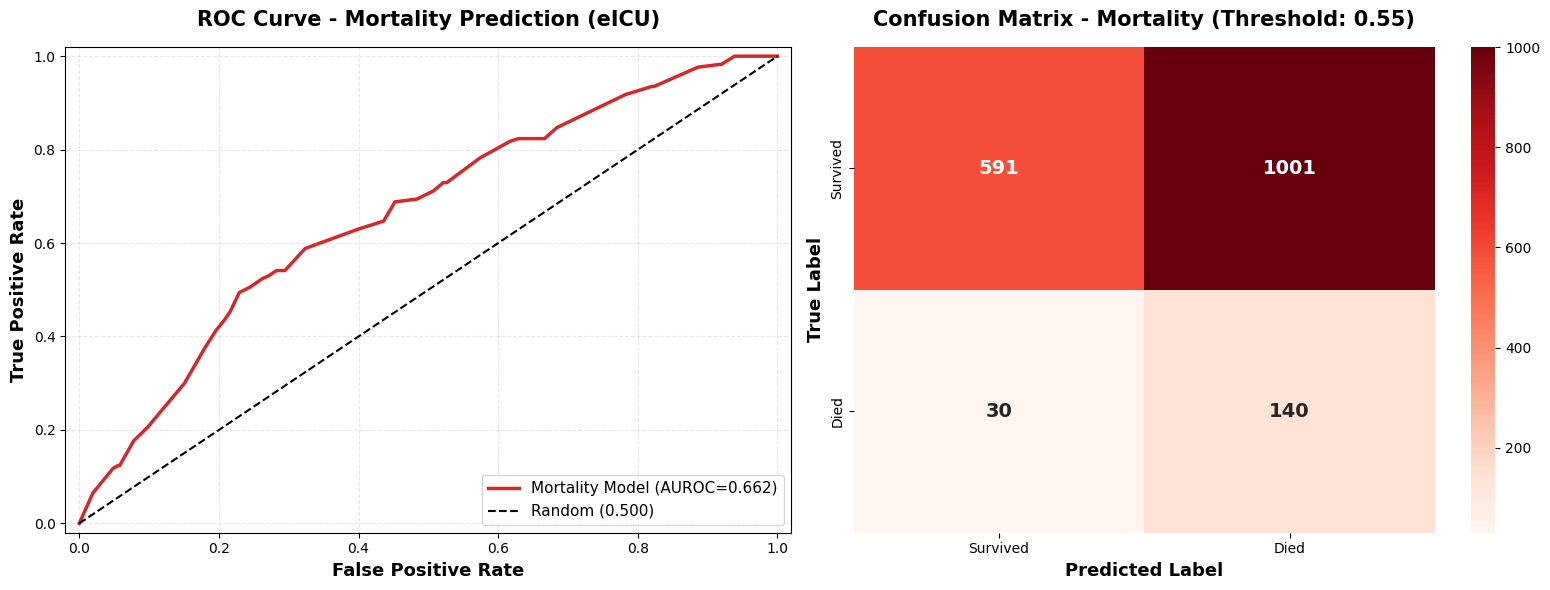

✅ 사망률 모델 그래프 저장 완료 (Threshold 0.55)


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("[사망률 모델 시각화 (Custom Threshold: 0.55)]")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# 1. ROC Curve (사망률)
# ============================================
fpr, tpr, _ = roc_curve(y_external_mortality, mortality_pred_proba)

axes[0].plot(fpr, tpr, label=f'Mortality Model (AUROC={auroc_mortality:.3f})',
                linewidth=2.5, color='#D62828')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (0.500)', linewidth=1.5)
axes[0].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_title('ROC Curve - Mortality Prediction (eICU)', fontsize=15, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# ============================================
# 2. Confusion Matrix (사망률) - Custom Threshold 0.55
# ============================================
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Reds', cbar=True,
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'],
            ax=axes[1], annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].set_title(f'Confusion Matrix - Mortality (Threshold: {custom_threshold})', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("✅ 사망률 모델 그래프 저장 완료 (Threshold 0.55)")
print("="*80)